# **Rome Airbnb Clusterization**

**Project**: Airbnb Market Segmentation Analysis

**Goal**: Cluster Rome's Airbnb listings using the final feature set from EDA & Feature Selection, testing systematically whether NLP-derived signals reveal market structure invisible to tabular features alone, resolving the geography input, tuning k and gamma, and validating cluster stability before profiling the resulting segments.

## 1. Setup & Preprocessing

### 1.1 Imports & Environment

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [22]:
ROME_PALETTE = {
    'primary': '#8B3A3A', 'secondary': '#4C6B8A', 'accent': '#C9A227',
    'neutral': '#6B6B6B', 'light_bg': '#F5F1EC',
}
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})

### 1.2 Data Loading

In [3]:
listings = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_final.csv')

In [4]:
listings.drop(columns = ['Unnamed: 0'], inplace = True)
print(f"shape: {listings.shape}")
print(f"\ndtypes:\n{listings.dtypes.value_counts()}")

shape: (35818, 149)

dtypes:
float64    86
str        45
int64      18
Name: count, dtype: int64


### 1.3 Split Features by Type

In [6]:
listing_ids = listings['id'].copy()
price = listings['price']
price_tier = listings['price_tier']

numeric_all = listings.select_dtypes(include=[np.number]).columns.tolist()
str_cols = listings.select_dtypes(include='str').columns.tolist()

EXCLUDE_FROM_NUMERIC = {'id', 'price'}

binary_cols = [c for c in numeric_all if c not in EXCLUDE_FROM_NUMERIC
               and set(listings[c].dropna().unique()).issubset({0, 1})]
continuous_cols = [c for c in numeric_all if c not in binary_cols and c not in EXCLUDE_FROM_NUMERIC]
categorical_cols = [c for c in str_cols if c != 'price_tier']

print(f"binary flags: {len(binary_cols)}")
print(f"continuous numeric: {len(continuous_cols)}")
print(f"string/nominal categorical: {len(categorical_cols)}")
print(f"\nid excluded from clustering inputs: {'id' not in continuous_cols and 'id' not in binary_cols}")
print(f"price excluded from clustering inputs: {'price' not in continuous_cols and 'price' not in binary_cols}")
print(f"price_tier excluded from clustering inputs: {'price_tier' not in categorical_cols}")

# sanity check: every clustering-relevant column accounted for exactly once
all_clustering_cols = binary_cols + continuous_cols + categorical_cols
print(f"\ntotal clustering-input columns: {len(all_clustering_cols)}")
print(f"total listings columns: {listings.shape[1]}")
print(f"expected gap: {listings.shape[1] - len(all_clustering_cols)}")

binary flags: 29
continuous numeric: 73
string/nominal categorical: 44

id excluded from clustering inputs: True
price excluded from clustering inputs: True
price_tier excluded from clustering inputs: True

total clustering-input columns: 146
total listings columns: 149
expected gap: 3


### 1.4 Build the Final Clustering Matrix

In [8]:
### 1.4 Build the Final Clustering Matrix
from sklearn.preprocessing import StandardScaler

X_categorical = listings[categorical_cols + binary_cols].copy()
for col in binary_cols:
    X_categorical[col] = X_categorical[col].astype(int).astype(str)

X_continuous = listings[continuous_cols].copy()
scaler = StandardScaler()
X_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(X_continuous),
    columns=continuous_cols,
    index=listings.index
)

print(f"X_categorical: {X_categorical.shape} ({len(categorical_cols)} nominal + {len(binary_cols)} binary-as-string)")
print(f"X_continuous_scaled: {X_continuous_scaled.shape}")

print(f"\nX_categorical any NaN: {X_categorical.isna().any().any()}")
print(f"X_continuous_scaled any NaN: {X_continuous_scaled.isna().any().any()}")
print(f"X_continuous_scaled mean: {X_continuous_scaled.mean().abs().max():.6f}")
print(f"X_continuous_scaled std: {X_continuous_scaled.std().min():.4f} to {X_continuous_scaled.std().max():.4f}")

X_categorical: (35818, 73) (44 nominal + 29 binary-as-string)
X_continuous_scaled: (35818, 73)

X_categorical any NaN: False
X_continuous_scaled any NaN: False
X_continuous_scaled mean: 0.000000
X_continuous_scaled std: 1.0000 to 1.0000


In [9]:
X_combined = pd.concat([X_continuous_scaled, X_categorical], axis=1)
categorical_indices = list(range(len(continuous_cols), len(continuous_cols) + len(X_categorical.columns)))

print(f"\nX_combined shape: {X_combined.shape}")
print(f"categorical column indices: {categorical_indices[0]} to {categorical_indices[-1]} "
      f"({len(categorical_indices)} categorical columns)")

# sanity check: id, price, price_tier genuinely absent from the clustering matrix
leaked = {'id', 'price', 'price_tier'} & set(X_combined.columns)
print(f"\nleaked external columns in X_combined: {leaked if leaked else 'none — clean'}")

# sanity check: row alignment between listing_ids and X_combined preserved throughout
print(f"listing_ids length: {len(listing_ids)}, X_combined length: {len(X_combined)}")
print(f"indices match: {(listing_ids.index == X_combined.index).all()}")


X_combined shape: (35818, 146)
categorical column indices: 73 to 145 (73 categorical columns)

leaked external columns in X_combined: none — clean
listing_ids length: 35818, X_combined length: 35818
indices match: True


`id`/`price`/`price_tier` were separated from the final feature set as external (kept for later profiling). The rest was split into continuous, binary, and nominal categorical, then scaled the continuous block and assembled the combined matrix `kmodes.KPrototypes` expects. Binary flags travel with the categorical block, as strings, so their weight in the distance is governed by `gamma` rather than `StandardScaler`'s per-column variance.

## 2. Geography Resolution

The final feature set carries two competing ways to encode a listing's location: `neighbourhood_cleansed` (15 administrative municipi, badly imbalanced) and `geo_sector` (8 compass directions from the city center, far more balanced). Both were kept as candidates in feature selection specifically because it needs an empirical answer.

This section builds two otherwise-identical backbone feature sets (Structure + Host + one geo variant each) and runs a full k-sweep (k=3..10) on both, comparing cost and Gower-based silhouette curves across the whole range rather than at a single arbitrary k. `distance_to_center_km_log` stays in both variants unchanged, as it was designed as a complementary radius-and-angle pair with `geo_sector`, not a substitute for either categorical option, and gets its own lightweight ablation check later rather than complicating this comparison.

### 2.1 Setup Backbone Variants

In [12]:
# backbone = tabular-only features (Geo + Structure + Host)
NLP_PATTERNS = ('density', 'topic', 'embedding', 'sentiment', 'text_persona', 'mtld', 'readability',
                 'n_embedded_reviews', 'landmark')

backbone_continuous_cols = [c for c in continuous_cols if not any(p in c for p in NLP_PATTERNS)]
backbone_categorical_cols = [c for c in categorical_cols if not any(p in c for p in NLP_PATTERNS)]
backbone_binary_cols = [c for c in binary_cols if not any(p in c for p in NLP_PATTERNS)]

print(f"backbone continuous: {len(backbone_continuous_cols)} (of {len(continuous_cols)} total)")
print(f"backbone categorical: {len(backbone_categorical_cols)} (of {len(categorical_cols)} total)")
print(f"backbone binary: {len(backbone_binary_cols)} (of {len(binary_cols)} total)")

backbone continuous: 16 (of 73 total)
backbone categorical: 14 (of 44 total)
backbone binary: 27 (of 29 total)


In [16]:
backbone_categorical_cols_A = [c for c in backbone_categorical_cols if c != 'geo_sector']  # keeps neighbourhood_cleansed
backbone_categorical_cols_B = [c for c in backbone_categorical_cols if c != 'neighbourhood_cleansed']  # keeps geo_sector

print(f"Variant A (neighbourhood_cleansed): {len(backbone_categorical_cols_A)} categorical cols")
print(f"Variant B (geo_sector): {len(backbone_categorical_cols_B)} categorical cols")
print(f"difference: {set(backbone_categorical_cols_A) ^ set(backbone_categorical_cols_B)}")

Variant A (neighbourhood_cleansed): 13 categorical cols
Variant B (geo_sector): 13 categorical cols
difference: {'geo_sector', 'neighbourhood_cleansed'}


### 2.2 Build Both Matrices

In [17]:
def build_kproto_matrix(continuous_cols_list, categorical_cols_list, binary_cols_list):
    """Assembles a combined DataFrame + categorical index list for KPrototypes,
    reusing the already-fitted scaler and already-stringified binary columns."""
    X_cat = X_categorical[categorical_cols_list + binary_cols_list]
    X_cont = X_continuous_scaled[continuous_cols_list]
    X_comb = pd.concat([X_cont, X_cat], axis=1)
    cat_idx = list(range(len(continuous_cols_list), X_comb.shape[1]))
    return X_comb, cat_idx

X_backbone_A, cat_idx_A = build_kproto_matrix(backbone_continuous_cols, backbone_categorical_cols_A, backbone_binary_cols)
X_backbone_B, cat_idx_B = build_kproto_matrix(backbone_continuous_cols, backbone_categorical_cols_B, backbone_binary_cols)

print(f"X_backbone_A (neighbourhood_cleansed): {X_backbone_A.shape}, categorical indices {cat_idx_A[0]}-{cat_idx_A[-1]}")
print(f"X_backbone_B (geo_sector): {X_backbone_B.shape}, categorical indices {cat_idx_B[0]}-{cat_idx_B[-1]}")

# sanity check: both variants must have identical shape (same number of columns overall)
print(f"\nshapes match: {X_backbone_A.shape == X_backbone_B.shape}")

X_backbone_A (neighbourhood_cleansed): (35818, 56), categorical indices 16-55
X_backbone_B (geo_sector): (35818, 56), categorical indices 16-55

shapes match: True


### 2.3 K-Sweep for Both Variants

In [18]:
from kmodes.kprototypes import KPrototypes
import time

K_RANGE = range(3, 11)
sweep_results = {'A': {}, 'B': {}}

for variant, (X_variant, cat_idx) in [('A', (X_backbone_A, cat_idx_A)), ('B', (X_backbone_B, cat_idx_B))]:
    print(f"\n=== Variant {variant} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_variant.to_numpy(), categorical=cat_idx)
        elapsed = time.time() - start

        sweep_results[variant][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== Variant A ===
  k=3: cost=596856.0, 27.9s
  k=4: cost=567644.6, 39.8s
  k=5: cost=546736.7, 40.6s
  k=6: cost=529106.6, 51.8s
  k=7: cost=512142.4, 50.0s
  k=8: cost=500195.9, 58.6s
  k=9: cost=487904.4, 101.8s
  k=10: cost=478360.4, 58.1s

=== Variant B ===
  k=3: cost=602117.0, 26.6s
  k=4: cost=572801.2, 36.9s
  k=5: cost=551788.6, 35.3s
  k=6: cost=534130.4, 65.0s
  k=7: cost=517177.0, 46.8s
  k=8: cost=505226.6, 83.5s
  k=9: cost=494821.8, 68.6s
  k=10: cost=483292.0, 61.6s


Both variants show smooth, monotonically decreasing cost with no sharp elbow at any single k. What's notable is how close the two variants track each other throughout: at every k, `neighbourhood_cleansed` (A) runs consistently ~1-2% lower in cost than `geo_sector` (B). Neither curve's shape suggests one geo variant restructures the market meaningfully differently from the other. If silhouette tells the same story, geography's *cost* contribution to clustering may not differentiate strongly between the two encodings, and the deciding factor will likely need to come from silhouette shape or cluster interpretability rather than raw cost.

### 2.4 Stratified Sampling & Gower Silhouette

In [21]:
import gower
from sklearn.metrics import silhouette_score

SAMPLE_SIZE = 8000
MIN_PER_CLUSTER = 30  # floor so small segments aren't sampled out entirely

def stratified_sample_indices(labels, sample_size=SAMPLE_SIZE, min_per_cluster=MIN_PER_CLUSTER, random_state=42):
    """Proportional stratified sample by cluster label, with a floor per cluster
    so rare segments survive the sample even if their proportional share would round to ~0."""
    rng = np.random.RandomState(random_state)
    labels_series = pd.Series(labels)
    cluster_sizes = labels_series.value_counts()

    sampled_idx = []
    for cluster_id, size in cluster_sizes.items():
        proportional_n = int(round(sample_size * size / len(labels_series)))
        n_to_sample = max(min_per_cluster, proportional_n)
        n_to_sample = min(n_to_sample, size)  # can't sample more than exists
        cluster_idx = labels_series[labels_series == cluster_id].index.to_numpy()
        chosen = rng.choice(cluster_idx, size=n_to_sample, replace=False)
        sampled_idx.extend(chosen)

    return np.array(sampled_idx)


def compute_gower_silhouette(X_variant, cat_idx, labels, sample_idx):
    """Computes Gower distance + silhouette on a sample, with categorical columns
    passed explicitly — gower's auto-detection via np.issubdtype breaks on
    pandas 3.x's native StringDtype, so we bypass it entirely."""
    X_sample = X_variant.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_features_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_features_mask[cat_idx] = True

    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_features_mask)
    return silhouette_score(gower_dist, labels_sample, metric='precomputed'), len(sample_idx)


for variant, (X_variant, cat_idx) in [('A', (X_backbone_A, cat_idx_A)), ('B', (X_backbone_B, cat_idx_B))]:
    print(f"\n=== Variant {variant} ===")
    for k in K_RANGE:
        labels = sweep_results[variant][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_variant, cat_idx, labels, sample_idx)

        sweep_results[variant][k]['silhouette'] = sil_score
        sweep_results[variant][k]['sample_size'] = n_sampled
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== Variant A ===
  k=3: silhouette=0.0953 (sample n=8000)
  k=4: silhouette=0.0711 (sample n=8000)
  k=5: silhouette=0.0580 (sample n=8000)
  k=6: silhouette=0.0532 (sample n=8000)
  k=7: silhouette=0.0546 (sample n=7999)
  k=8: silhouette=0.0489 (sample n=7999)
  k=9: silhouette=0.0385 (sample n=7999)
  k=10: silhouette=0.0311 (sample n=8000)

=== Variant B ===
  k=3: silhouette=0.0935 (sample n=8000)
  k=4: silhouette=0.0701 (sample n=7999)
  k=5: silhouette=0.0610 (sample n=8001)
  k=6: silhouette=0.0525 (sample n=8000)
  k=7: silhouette=0.0521 (sample n=8001)
  k=8: silhouette=0.0503 (sample n=7999)
  k=9: silhouette=0.0461 (sample n=7999)
  k=10: silhouette=0.0322 (sample n=8000)


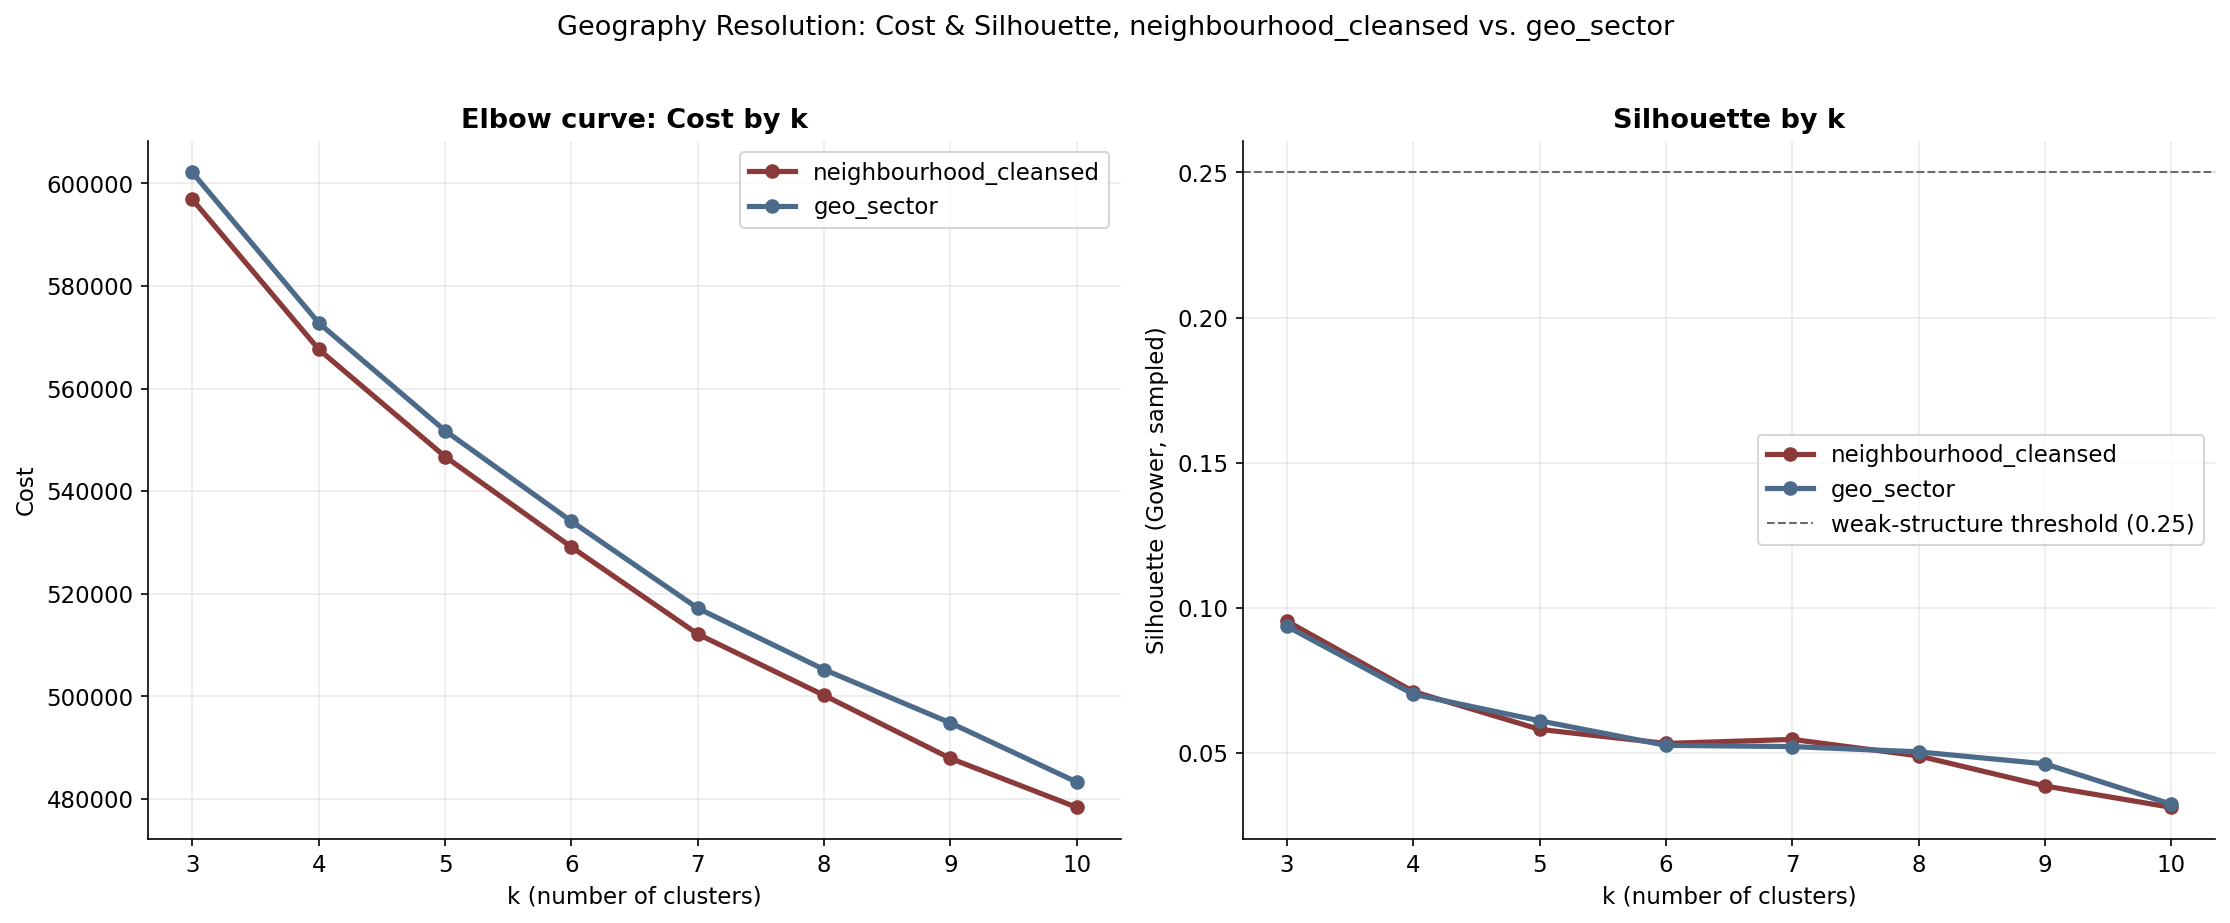

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for variant, color, label in [('A', ROME_PALETTE['primary'], 'neighbourhood_cleansed'),
                                ('B', ROME_PALETTE['secondary'], 'geo_sector')]:
    costs = [sweep_results[variant][k]['cost'] for k in K_RANGE]
    axes[0].plot(list(K_RANGE), costs, marker='o', color=color, linewidth=2.5, label=label)

axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Cost')
axes[0].set_title('Elbow curve: Cost by k')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

for variant, color, label in [('A', ROME_PALETTE['primary'], 'neighbourhood_cleansed'),
                                ('B', ROME_PALETTE['secondary'], 'geo_sector')]:
    sils = [sweep_results[variant][k]['silhouette'] for k in K_RANGE]
    axes[1].plot(list(K_RANGE), sils, marker='o', color=color, linewidth=2.5, label=label)

axes[1].axhline(0.25, color=ROME_PALETTE['neutral'], linestyle='--', linewidth=1, label='weak-structure threshold (0.25)')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette (Gower, sampled)')
axes[1].set_title('Silhouette by k')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.suptitle('Geography Resolution: Cost & Silhouette, neighbourhood_cleansed vs. geo_sector', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both geo variants produce nearly identical cost and silhouette curves at every k. A difference of 0.001-0.002 in silhouette, far smaller than the variation across k itself. This means the geography *encoding* choice barely affects how cleanly K-Prototypes separates the backbone feature space, even though geography was consistently the strongest price driver throughout the EDA, meaning that "predicts price well" and "drives cluster separation" are different questions. Silhouette peaks at k=3 for both (≈0.095) and declines monotonically as k grows, staying well below the conventional 0.25 threshold for "weak but real" structure across the whole range.

Given how closely A and B track each other, the deciding factor for which geo variant to carry forward isn't cost or silhouette, as neither shows a measurable advantage. The choice instead rests on a known structural risk flagged back in the EDA notebook: `neighbourhood_cleansed`'s severe imbalance (49% of listings concentrated in one category) versus `geo_sector`'s far more even 8-way split. At equal measured quality, the safer encoding is preferred. **`geo_sector` is carried forward as the geography input.**

The weak silhouette score is consistent across both variants and should be treated as a warning. It may be caused by an uncalibrated default gamma, which is automatically calculated separately for each fit in the sweep and is never tuned. Alternatively, it may indicate that the market has a genuinely weak structure, with a continuous gradient rather than clearly separated segments. Both factors may also contribute.

## 3. Baseline Tuning

The geography analysis identified the best geography variable, but the silhouette score remained low across all k values and both geography variants. This section tests different k and gamma values to determine whether the weak clustering was caused by the default gamma or reflects the actual structure of the market.

### 3.1 Setup the Gamma Range

In [25]:
# kmodes' default gamma = mean std of the numeric columns
default_gamma = X_backbone_B[backbone_continuous_cols].std().mean()
print(f"kmodes default gamma: {default_gamma:.4f}")

GAMMA_RANGE = [default_gamma * m for m in [0.25, 0.5, 1.0, 2.0, 4.0]]
print(f"\ngamma grid: {[round(g, 4) for g in GAMMA_RANGE]}")

kmodes default gamma: 1.0000

gamma grid: [np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(4.0001)]


### 3.2 Full k×gamma Grid on Backbone 

In [26]:
K_RANGE = range(3, 11)
baseline_grid_results = {}

for gamma in GAMMA_RANGE:
    gamma_key = round(gamma, 4)
    baseline_grid_results[gamma_key] = {}
    print(f"\n=== gamma={gamma_key} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, gamma=gamma, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_backbone_B.to_numpy(), categorical=cat_idx_B)
        elapsed = time.time() - start

        baseline_grid_results[gamma_key][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== gamma=0.25 ===
  k=3: cost=531397.2, 29.7s
  k=4: cost=503283.4, 39.9s
  k=5: cost=482831.9, 40.1s
  k=6: cost=464294.9, 75.9s
  k=7: cost=447008.6, 41.6s
  k=8: cost=435166.4, 50.5s
  k=9: cost=425576.1, 93.9s
  k=10: cost=416544.3, 177.3s

=== gamma=0.5 ===
  k=3: cost=602119.0, 28.1s
  k=4: cost=572803.2, 36.3s
  k=5: cost=551790.5, 35.4s
  k=6: cost=534132.4, 62.8s
  k=7: cost=517178.9, 44.7s
  k=8: cost=505228.5, 82.3s
  k=9: cost=494823.6, 68.2s
  k=10: cost=483293.8, 62.3s

=== gamma=1.0 ===
  k=3: cost=742124.9, 25.3s
  k=4: cost=719667.9, 89.0s
  k=5: cost=686744.3, 49.7s
  k=6: cost=670088.2, 67.3s
  k=7: cost=650438.9, 61.8s
  k=8: cost=643101.4, 48.5s
  k=9: cost=630794.8, 52.9s
  k=10: cost=618490.4, 55.0s

=== gamma=2.0 ===
  k=3: cost=1021509.3, 29.1s
  k=4: cost=978598.0, 29.7s
  k=5: cost=947724.1, 27.4s
  k=6: cost=929873.4, 46.1s
  k=7: cost=908176.2, 49.6s
  k=8: cost=895334.1, 53.0s
  k=9: cost=883895.0, 37.5s
  k=10: cost=875225.2, 55.9s

=== gamma=4.0001 ===

### 3.2 Stratified Sampling & Gower Silhouette

In [27]:
for gamma_key in baseline_grid_results:
    print(f"\n=== gamma={gamma_key} ===")
    for k in K_RANGE:
        labels = baseline_grid_results[gamma_key][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_backbone_B, cat_idx_B, labels, sample_idx)

        baseline_grid_results[gamma_key][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== gamma=0.25 ===
  k=3: silhouette=0.0867 (sample n=8000)
  k=4: silhouette=0.0679 (sample n=8000)
  k=5: silhouette=0.0549 (sample n=8000)
  k=6: silhouette=0.0501 (sample n=8001)
  k=7: silhouette=0.0397 (sample n=8001)
  k=8: silhouette=0.0403 (sample n=8000)
  k=9: silhouette=0.0305 (sample n=8000)
  k=10: silhouette=0.0240 (sample n=7999)

=== gamma=0.5 ===
  k=3: silhouette=0.0935 (sample n=8000)
  k=4: silhouette=0.0701 (sample n=7999)
  k=5: silhouette=0.0610 (sample n=8001)
  k=6: silhouette=0.0518 (sample n=8000)
  k=7: silhouette=0.0521 (sample n=8001)
  k=8: silhouette=0.0503 (sample n=7999)
  k=9: silhouette=0.0461 (sample n=7999)
  k=10: silhouette=0.0322 (sample n=8000)

=== gamma=1.0 ===
  k=3: silhouette=0.1045 (sample n=7999)
  k=4: silhouette=0.0754 (sample n=8001)
  k=5: silhouette=0.0736 (sample n=8001)
  k=6: silhouette=0.0632 (sample n=8000)
  k=7: silhouette=0.0652 (sample n=7999)
  k=8: silhouette=0.0571 (sample n=8000)
  k=9: silhouette=0.0525 (sample n=800

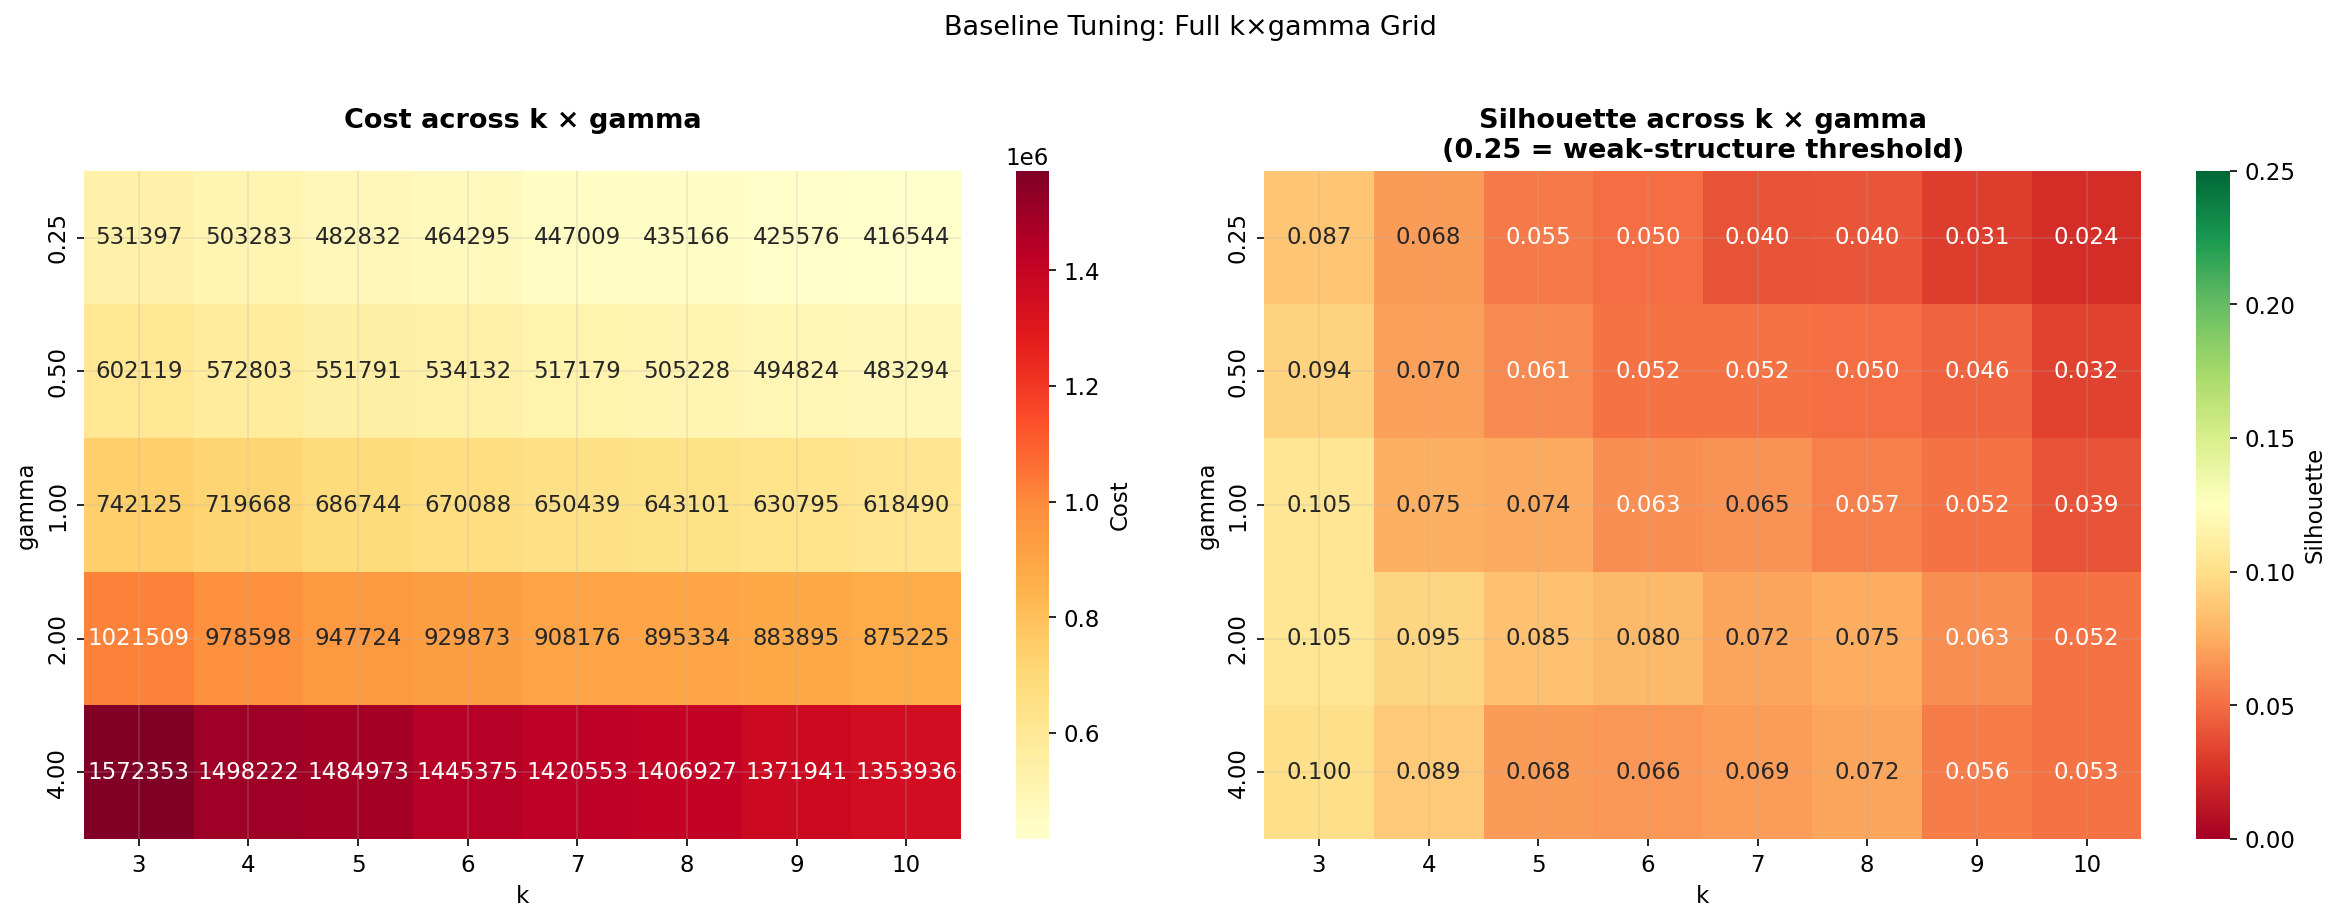

best combination: gamma=2.0, k=3, silhouette=0.1049


In [29]:
gamma_labels = [f'{g:.2f}' for g in baseline_grid_results.keys()]
k_labels = list(K_RANGE)

cost_matrix = np.array([[baseline_grid_results[g][k]['cost'] for k in K_RANGE] for g in baseline_grid_results])
sil_matrix = np.array([[baseline_grid_results[g][k]['silhouette'] for k in K_RANGE] for g in baseline_grid_results])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cost_matrix, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=k_labels, yticklabels=gamma_labels,
            ax=axes[0], cbar_kws={'label': 'Cost'})
axes[0].set_xlabel('k')
axes[0].set_ylabel('gamma')
axes[0].set_title('Cost across k × gamma\n')

sns.heatmap(sil_matrix, annot=True, fmt='.3f', cmap='RdYlGn', xticklabels=k_labels, yticklabels=gamma_labels,
            ax=axes[1], vmin=0, vmax=0.25, cbar_kws={'label': 'Silhouette'})
axes[1].set_xlabel('k')
axes[1].set_ylabel('gamma')
axes[1].set_title('Silhouette across k × gamma\n(0.25 = weak-structure threshold)')

plt.suptitle('Baseline Tuning: Full k×gamma Grid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_gamma_key = max(baseline_grid_results, key=lambda g: max(baseline_grid_results[g][k]['silhouette'] for k in K_RANGE))
best_k = max(K_RANGE, key=lambda k: baseline_grid_results[best_gamma_key][k]['silhouette'])
best_sil = baseline_grid_results[best_gamma_key][best_k]['silhouette']
print(f"best combination: gamma={best_gamma_key}, k={best_k}, silhouette={best_sil:.4f}")

The full grid confirms the result from Section 2. The silhouette score is highest at k=3 for all gamma values and decreases as k increases. Gamma has some effect, with gamma=2.0 giving the best result of 0.1049, compared with 0.095 using the default gamma. However, the improvement is small, and the score is still below 0.25.

This suggests that the weak silhouette is not mainly caused by gamma. The features geo_sector, Structure, and Host do not form clearly separated clusters. Instead, the market seems to have continuous and overlapping differences in factors such as price, size, and location. Whether NLP features can improve this structure is the main question for the next section.

## 4. NLP Features 

Previous section defined the baseline using geo_sector, Structure, and Host, with k=3 and gamma=2.0. The silhouette score was still low at 0.1049, suggesting that the market has overlapping groups rather than clearly separated segments. The main question of this section is whether adding text features changes this picture.

Three NLP feature groups are tested separately: embeddings and persona in Experiment A, tone and topic features in Experiment B, and all NLP features together in Experiment C. Each experiment uses the same baseline and gamma=2.0. The goal is not only to see whether the silhouette score improves, but also to check whether NLP creates different clusters using the Adjusted Rand Index (ARI) and to understand what changes.

### 4.1 Setup 

In [30]:
EMBEDDING_PERSONA_PATTERNS = ('embedding', 'text_persona', 'n_embedded_reviews')
nlp_group_A_continuous = [c for c in continuous_cols if any(p in c for p in EMBEDDING_PERSONA_PATTERNS)]
nlp_group_A_categorical = [c for c in categorical_cols if any(p in c for p in EMBEDDING_PERSONA_PATTERNS)]
nlp_group_A_binary = [c for c in binary_cols if any(p in c for p in EMBEDDING_PERSONA_PATTERNS)]

all_nlp_continuous = [c for c in continuous_cols if any(p in c for p in NLP_PATTERNS)]
all_nlp_categorical = [c for c in categorical_cols if any(p in c for p in NLP_PATTERNS)]
all_nlp_binary = [c for c in binary_cols if any(p in c for p in NLP_PATTERNS)]

nlp_group_B_continuous = [c for c in all_nlp_continuous if c not in nlp_group_A_continuous]
nlp_group_B_categorical = [c for c in all_nlp_categorical if c not in nlp_group_A_categorical]
nlp_group_B_binary = [c for c in all_nlp_binary if c not in nlp_group_A_binary]

print(f"Group A (embeddings/persona): {len(nlp_group_A_continuous)} continuous, "
      f"{len(nlp_group_A_categorical)} categorical, {len(nlp_group_A_binary)} binary")
print(f"Group B (tone/topics/sentiment): {len(nlp_group_B_continuous)} continuous, "
      f"{len(nlp_group_B_categorical)} categorical, {len(nlp_group_B_binary)} binary")

# sanity check: A + B should reconstruct the full NLP set exactly, no overlap or gap
a_plus_b_cont = set(nlp_group_A_continuous) | set(nlp_group_B_continuous)
a_plus_b_cat = set(nlp_group_A_categorical) | set(nlp_group_B_categorical)
a_plus_b_bin = set(nlp_group_A_binary) | set(nlp_group_B_binary)

print(f"\nA+B reconstructs full NLP continuous: {a_plus_b_cont == set(all_nlp_continuous)}")
print(f"A+B reconstructs full NLP categorical: {a_plus_b_cat == set(all_nlp_categorical)}")
print(f"A+B reconstructs full NLP binary: {a_plus_b_bin == set(all_nlp_binary)}")

Group A (embeddings/persona): 11 continuous, 1 categorical, 0 binary
Group B (tone/topics/sentiment): 46 continuous, 29 categorical, 2 binary

A+B reconstructs full NLP continuous: True
A+B reconstructs full NLP categorical: True
A+B reconstructs full NLP binary: True


### 4.2 Build Three Matrices

In [33]:
def build_experiment_matrix(extra_continuous, extra_categorical, extra_binary):
    """Backbone (geo_sector variant) + a given NLP feature group, using the
    same assembly logic as build_kproto_matrix throughout this notebook."""
    continuous_list = backbone_continuous_cols + extra_continuous
    categorical_list = backbone_categorical_cols_B + extra_categorical  # backbone already uses geo_sector
    binary_list = backbone_binary_cols + extra_binary
    return build_kproto_matrix(continuous_list, categorical_list, binary_list)

X_exp_A, cat_idx_A_exp = build_experiment_matrix(nlp_group_A_continuous, nlp_group_A_categorical, nlp_group_A_binary)
X_exp_B, cat_idx_B_exp = build_experiment_matrix(nlp_group_B_continuous, nlp_group_B_categorical, nlp_group_B_binary)
X_exp_C, cat_idx_C_exp = build_experiment_matrix(all_nlp_continuous, all_nlp_categorical, all_nlp_binary)

for name, X_exp in [('A (embeddings/persona)', X_exp_A), ('B (tone/topics)', X_exp_B), ('C (full NLP)', X_exp_C)]:
    print(f"Experiment {name}: {X_exp.shape}")

print(f"\nBaseline shape: {X_backbone_B.shape}")

Experiment A (embeddings/persona): (35818, 68)
Experiment B (tone/topics): (35818, 133)
Experiment C (full NLP): (35818, 145)

Baseline shape: (35818, 56)


### 4.3 K-Sweep for Each Experiment

In [34]:
FIXED_GAMMA = 2.0
experiments = {
    'A': (X_exp_A, cat_idx_A_exp),
    'B': (X_exp_B, cat_idx_B_exp),
    'C': (X_exp_C, cat_idx_C_exp),
}

nlp_sweep_results = {}

for exp_name, (X_exp, cat_idx) in experiments.items():
    nlp_sweep_results[exp_name] = {}
    print(f"\n=== Experiment {exp_name} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, gamma=FIXED_GAMMA, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_exp.to_numpy(), categorical=cat_idx)
        elapsed = time.time() - start

        nlp_sweep_results[exp_name][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")



=== Experiment A ===
  k=3: cost=1407680.7, 34.2s
  k=4: cost=1360936.0, 57.3s
  k=5: cost=1335558.7, 43.7s
  k=6: cost=1310796.2, 44.2s
  k=7: cost=1291412.4, 36.3s
  k=8: cost=1263429.0, 70.2s
  k=9: cost=1255848.2, 60.9s
  k=10: cost=1241602.7, 77.0s

=== Experiment B ===
  k=3: cost=3281033.3, 33.8s
  k=4: cost=3237839.2, 40.7s
  k=5: cost=3158519.7, 48.3s
  k=6: cost=3101145.7, 38.9s
  k=7: cost=3068891.9, 49.5s
  k=8: cost=3080372.5, 61.9s
  k=9: cost=3066021.9, 67.6s
  k=10: cost=3023876.3, 78.7s

=== Experiment C ===
  k=3: cost=3668700.5, 35.6s
  k=4: cost=3611151.2, 41.2s
  k=5: cost=3532143.3, 46.4s
  k=6: cost=3501034.2, 64.9s
  k=7: cost=3444948.4, 60.7s
  k=8: cost=3412899.3, 83.8s
  k=9: cost=3419227.6, 64.4s
  k=10: cost=3371791.6, 81.5s


### 4.4 Stratified Sampling & Gower Silhouette

In [35]:
for exp_name, (X_exp, cat_idx) in experiments.items():
    print(f"\n=== Experiment {exp_name} ===")
    for k in K_RANGE:
        labels = nlp_sweep_results[exp_name][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_exp, cat_idx, labels, sample_idx)

        nlp_sweep_results[exp_name][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== Experiment A ===
  k=3: silhouette=0.1144 (sample n=8000)
  k=4: silhouette=0.1050 (sample n=8000)
  k=5: silhouette=0.0920 (sample n=8001)
  k=6: silhouette=0.0948 (sample n=8000)
  k=7: silhouette=0.0740 (sample n=8000)
  k=8: silhouette=0.0782 (sample n=8001)
  k=9: silhouette=0.0792 (sample n=8000)
  k=10: silhouette=0.0668 (sample n=8000)

=== Experiment B ===
  k=3: silhouette=0.1644 (sample n=8000)
  k=4: silhouette=0.1018 (sample n=8000)
  k=5: silhouette=0.1099 (sample n=8001)
  k=6: silhouette=0.1209 (sample n=8000)
  k=7: silhouette=0.0960 (sample n=7999)
  k=8: silhouette=0.0908 (sample n=7998)
  k=9: silhouette=0.0832 (sample n=8000)
  k=10: silhouette=0.0791 (sample n=7999)

=== Experiment C ===
  k=3: silhouette=0.1640 (sample n=8000)
  k=4: silhouette=0.1127 (sample n=8000)
  k=5: silhouette=0.1349 (sample n=8000)
  k=6: silhouette=0.1242 (sample n=8000)
  k=7: silhouette=0.1041 (sample n=8001)
  k=8: silhouette=0.1023 (sample n=8000)
  k=9: silhouette=0.0934 (samp

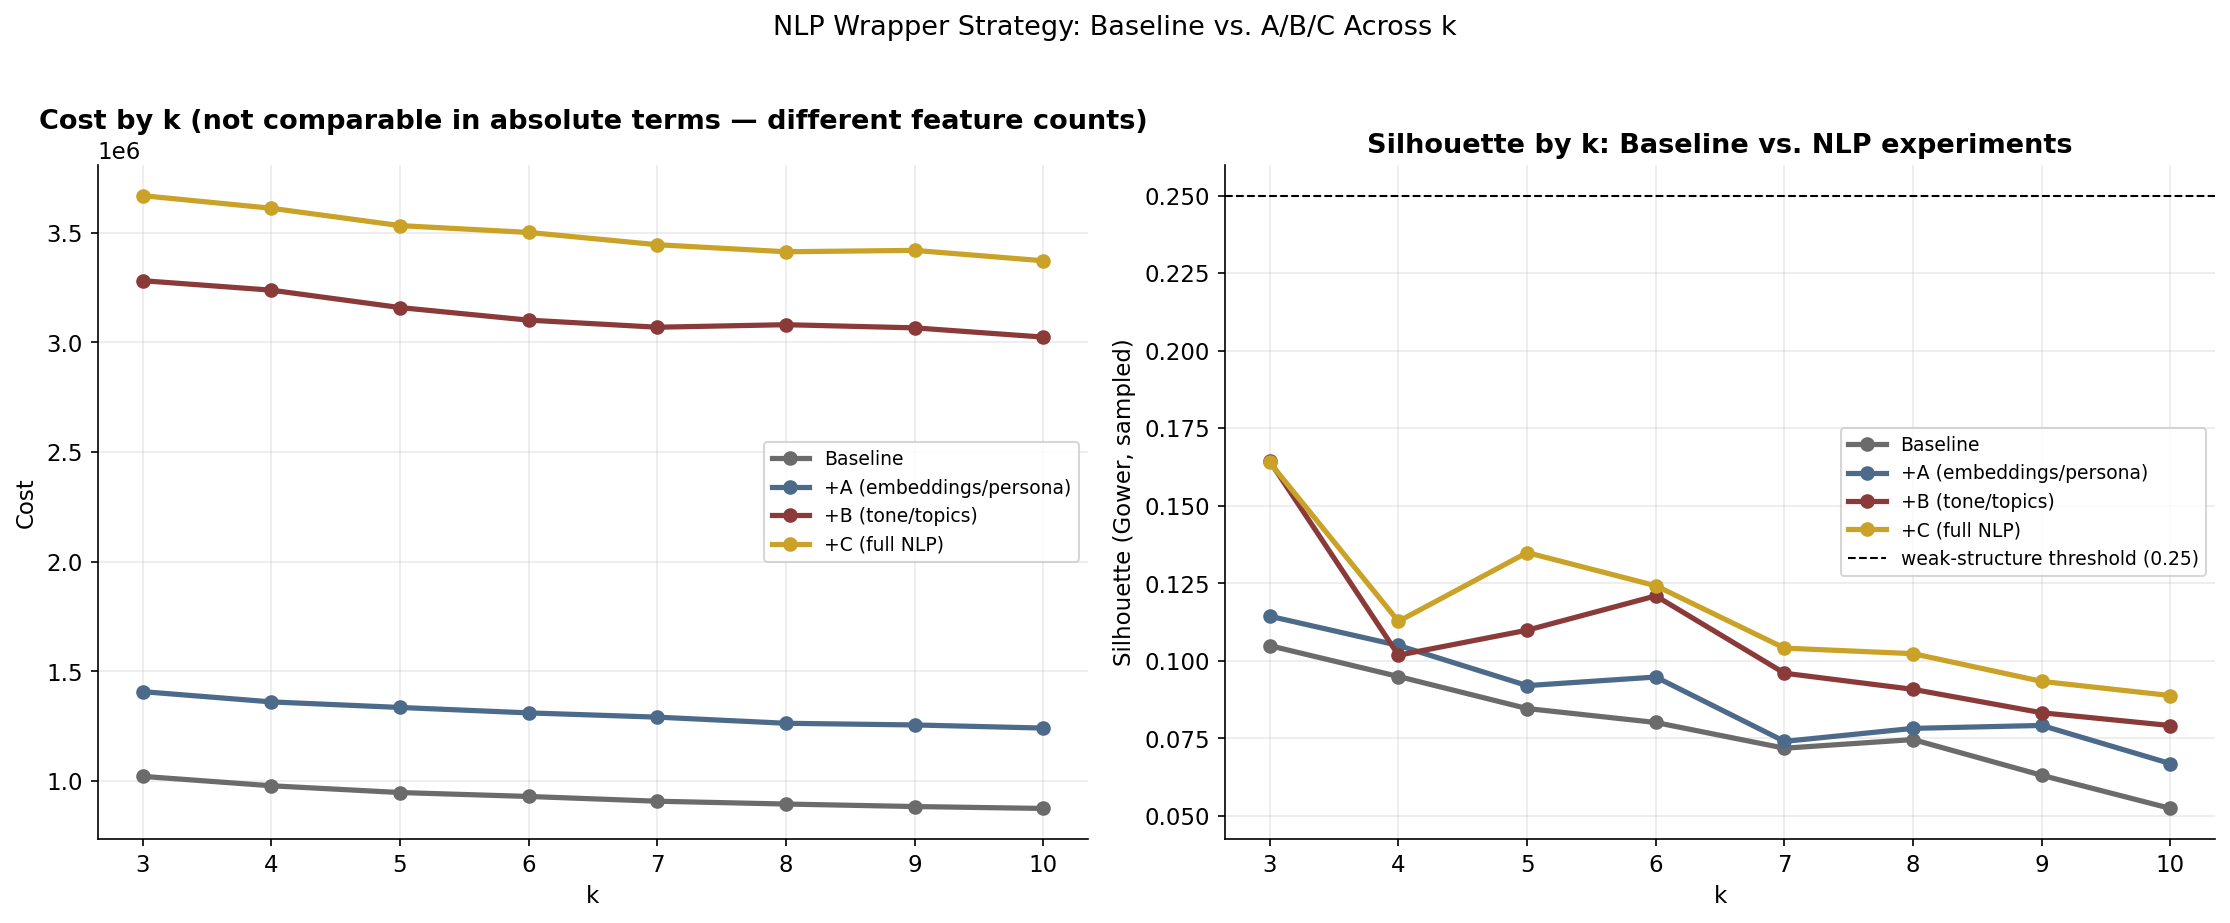

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

configs = [
    ('Baseline', baseline_grid_results[2.0], ROME_PALETTE['neutral']),
    ('+A (embeddings/persona)', nlp_sweep_results['A'], ROME_PALETTE['secondary']),
    ('+B (tone/topics)', nlp_sweep_results['B'], ROME_PALETTE['primary']),
    ('+C (full NLP)', nlp_sweep_results['C'], ROME_PALETTE['accent']),
]

for label, results, color in configs:
    costs = [results[k]['cost'] for k in K_RANGE]
    axes[0].plot(list(K_RANGE), costs, marker='o', color=color, linewidth=2.5, label=label)

axes[0].set_xlabel('k')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost by k (not comparable in absolute terms — different feature counts)')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend(fontsize=9)

for label, results, color in configs:
    sils = [results[k]['silhouette'] for k in K_RANGE]
    axes[1].plot(list(K_RANGE), sils, marker='o', color=color, linewidth=2.5, label=label)

axes[1].axhline(0.25, color='black', linestyle='--', linewidth=1, label='weak-structure threshold (0.25)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (Gower, sampled)')
axes[1].set_title('Silhouette by k: Baseline vs. NLP experiments')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend(fontsize=9)

plt.suptitle('NLP Wrapper Strategy: Baseline vs. A/B/C Across k', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Silhouette peaks at k=3 for all three experiments, then declines with occasional local bumps rather than a clean monotonic drop. A secondary local peak appears at k=6 for both A and B, and a distinct, standalone peak at k=5 for C that neither A nor B shows at that same k individually. That C-specific k=5 peak is the more interesting signal: it suggests the two NLP groups aren't just redundant with each other at that k, but combine into something neither produces alone.

Across the whole range, B and C track each other closely, while A stays consistently lower, reinforcing the earlier finding that tone/topic stylometry, not the compact embedding/persona representation, is driving most of the improvement over baseline.

### 4.5 ARI Comparison

In [38]:
from sklearn.metrics import adjusted_rand_score

ACTIVE_K_BY_EXPERIMENT = {
    'A': [3, 5, 6],
    'B': [3, 5, 6],
    'C': [3, 5, 6],
}

ari_results = []
for exp_name, k_list in ACTIVE_K_BY_EXPERIMENT.items():
    for k in k_list:
        baseline_labels = baseline_grid_results[2.0][k]['labels']
        exp_labels = nlp_sweep_results[exp_name][k]['labels']
        ari = adjusted_rand_score(baseline_labels, exp_labels)
        ari_results.append({'experiment': exp_name, 'k': k, 'ARI': round(ari, 4)})

ari_df = pd.DataFrame(ari_results)
display(ari_df)

,experiment,k,ARI
0,A,3,0.7488
1,A,5,0.3858
2,A,6,0.4195
3,B,3,0.3398
4,B,5,0.2304
5,B,6,0.3035
6,C,3,0.3446
7,C,5,0.2833
8,C,6,0.3074


Every ARI value falls in a genuinely informative middle range, meaning no experiment simply reproduces baseline's structure, but none scrambles it into something unrecognizable either. This confirms NLP is doing real, substantive reshuffling, not cosmetic relabeling.

`A` at k=3 is the clear outlier toward similarity, consistent with its weak silhouette gain: embeddings/persona alone mostly confirm the tabular partition rather than restructuring it. Every other cell sits in the 0.23-0.42 range, with `B` at k=5 showing the most substantial reshuffling of any combination tested. This is the strongest candidate for a direct crosstab: whatever moved between baseline and `B`'s k=5 partition is the most content-rich place to look for what NLP actually changed about the market's segmentation.

### 4.6 Crosstab

In [39]:
CROSSTAB_CANDIDATES = [('A', 3), ('B', 5), ('C', 5), ('B', 6)]

for exp_name, k in CROSSTAB_CANDIDATES:
    baseline_labels = baseline_grid_results[2.0][k]['labels']
    exp_labels = nlp_sweep_results[exp_name][k]['labels']

    crosstab = pd.crosstab(
        pd.Series(baseline_labels, name='Baseline cluster'),
        pd.Series(exp_labels, name=f'{exp_name} cluster (k={k})')
    )

    ari_value = ari_df[(ari_df.experiment == exp_name) & (ari_df.k == k)]['ARI'].values[0]
    print(f"\n=== Baseline vs. Experiment {exp_name}, k={k} (ARI={ari_value:.4f}) ===")
    display(crosstab)


=== Baseline vs. Experiment A, k=3 (ARI=0.7488) ===


A cluster (k=3),0,1,2
Baseline cluster,,,
0,100,910,14188
1,6043,6,740
2,76,12592,1163



=== Baseline vs. Experiment B, k=5 (ARI=0.2304) ===


B cluster (k=5),0,1,2,3,4
Baseline cluster,,,,,
0,90,375,4933,112,17
1,3868,3485,891,2518,74
2,2629,503,416,1670,535
3,618,494,0,1645,3610
4,522,1750,618,624,3821



=== Baseline vs. Experiment C, k=5 (ARI=0.2833) ===


C cluster (k=5),0,1,2,3,4
Baseline cluster,,,,,
0,13,4930,155,86,343
1,60,886,2778,811,6301
2,514,405,1723,735,2376
3,3671,0,1505,843,348
4,3228,566,828,2617,96



=== Baseline vs. Experiment B, k=6 (ARI=0.3035) ===


B cluster (k=6),0,1,2,3,4,5
Baseline cluster,,,,,,
0,82,64,5235,1133,976,745
1,422,134,1434,867,1079,367
2,884,7,1671,130,3272,514
3,2727,0,180,0,552,568
4,3461,116,363,376,873,2332
5,0,5019,90,119,14,12


Reading each table row by row reveals a consistent pattern across B and C: one baseline cluster (Baseline 0 in B/C's k=5, Baseline 5 in B's k=6) survives essentially unchanged even after adding text, being a genuinely stable segment robust to feature choice. Everywhere else, real restructuring happens: Baseline cluster 1 splits into three comparably-sized parts under B (k=5), and spreads across all six B clusters (k=6) with no dominant destination at all. A cluster the tabular model treated as one, that text sees as genuinely heterogeneous. Simultaneously, Baseline clusters 3 and 4 partially merge into a shared destination cluster under both B and C, at both k=5 and k=6, suggesting text collapses a distinction the tabular baseline drew between these two groups, treating them as more similar than geography/structure/host alone would.

`A` at k=3, by contrast, shows a near-pure one-to-one relabeling with no splits or merges — consistent with its high ARI and modest silhouette gain: embeddings/persona alone mostly confirm, rather than restructure, the tabular partition.

### 4.7 NLP Features Conclusion

This section answers the main question directly: text changes the market's cluster structure, measurably and substantively, not just cosmetically. Silhouette rose from baseline's 0.1049 to as high as 0.1644 (Experiment B, tone/topics). The tone and topic stylometry block, not the compact embeddings/persona representation, drives almost all of that gain, with `A` contributing only a marginal +9%. Both remain below the conventional 0.25 threshold, so this is still, in absolute terms, moderate rather than textbook-clean structure, but the *relative* improvement from adding text is real and consistent across k.

ARI confirms this wasn't just a metric artifact: every experiment except `A` at k=3 produced genuinely reshuffled partitions, not a relabeled copy of baseline. The crosstabs show *why*, as one baseline cluster survives essentially untouched across every NLP configuration tested, a stable segment the tabular features already captured correctly on their own. Everywhere else, text does real work: one baseline cluster splits into three-to-six genuinely distinct pieces under tone/topic features, revealing heterogeneity the tabular model had flattened into one group, while two other baseline clusters partially merge once text enters the picture, suggesting geography/structure/host alone drew a distinction that guest and host language doesn't actually support.

`C` (full NLP) tracks `B` closely at k=3 but pulls meaningfully ahead at k=5 (0.1349 vs. 0.1099 for B and 0.0920 for A alone). The two NLP groups appear to contribute complementary, not merely overlapping, signal at that specific k. Combined with `B`'s consistently strong standalone performance, `B` (tone/topics) at k=5 emerges as the strongest single candidate carried into the final re-tuning as it produced the most substantial restructuring while keeping silhouette competitive with the full NLP set, without embeddings/persona's comparatively weak individual contribution diluting the signal. `C` (full NLP) at k=5 is a close second, being the second-lowest ARI and the only configuration where silhouette actually exceeds both A and B individually at the same k, hinting at genuine complementary signal between the two NLP groups rather than mere overlap. Both `B` k=5 and `C` k=5 carry forward into the re-tuning as the two candidates worth a full gamma sweep.